In [80]:
import pandas as pd
df = pd.read_csv("synthetic_fraud_dataset.csv")

In [81]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [82]:
df.tail()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0
9999,6451,429,54.028632,ATM,Electronics,DE,11,0.096438,0.042823,0


In [83]:
df.shape

(10000, 10)

In [84]:
df.info

<bound method DataFrame.info of       transaction_id  user_id       amount transaction_type merchant_category  \
0               9608      363  4922.587542              ATM            Travel   
1                456      692    48.018303               QR              Food   
2               4747      587   136.881960           Online            Travel   
3               6934      445    80.534719              POS          Clothing   
4               1646      729   120.041158           Online           Grocery   
...              ...      ...          ...              ...               ...   
9995            1076      482    58.366442              POS          Clothing   
9996            4995      904   139.502160              POS            Travel   
9997            3485      527    71.012122           Online            Travel   
9998            7922      771    21.031405               QR           Grocery   
9999            6451      429    54.028632              ATM       Electronics

In [85]:
df.isnull().sum()

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df["is_fraud"].value_counts()

is_fraud
0    9500
1     500
Name: count, dtype: int64

In [88]:
df["is_fraud"].value_counts(normalize=True)*100

is_fraud
0    95.0
1     5.0
Name: proportion, dtype: float64

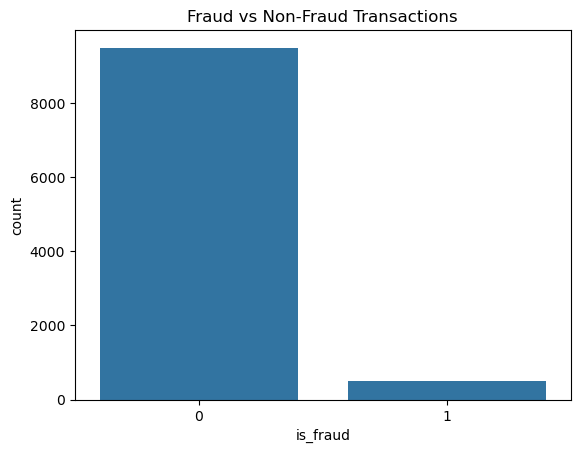

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [90]:
pd.crosstab(df["transaction_type"],df["is_fraud"])

is_fraud,0,1
transaction_type,,
ATM,2391,138
Online,2271,126
POS,2452,116
QR,2386,120


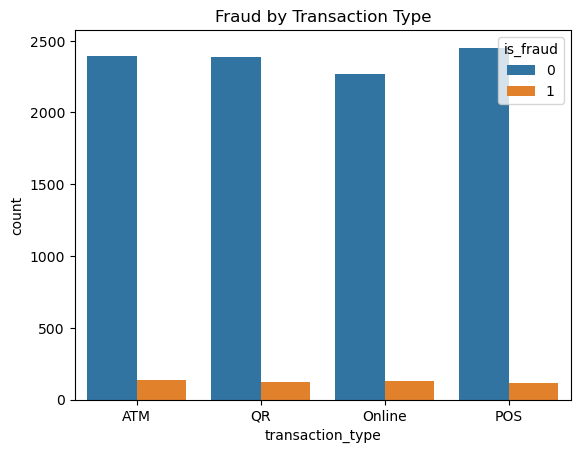

In [91]:
sns.countplot(
    x='transaction_type',
    hue='is_fraud',
    data=df
)

plt.title("Fraud by Transaction Type")
plt.show()

In [92]:
df.groupby('is_fraud')[['amount',
                        'device_risk_score',
                        'ip_risk_score']].mean()

,amount,device_risk_score,ip_risk_score
is_fraud,,,
0,100.277751,0.148290,0.149558
1,1657.577984,0.857951,0.851770


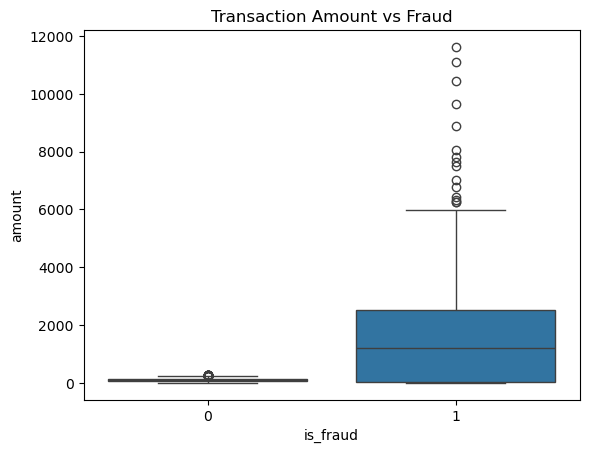

In [93]:
sns.boxplot(x='is_fraud', y='amount', data=df)

plt.title("Transaction Amount vs Fraud")
plt.show()

In [94]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'transaction_type',
        'merchant_category',
        'country'
    ],
    drop_first=True
)

df_encoded.head()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud,transaction_type_Online,transaction_type_POS,transaction_type_QR,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_FR,country_NG,country_TR,country_UK,country_US
0,9608,363,4922.587542,12,0.992347,0.947908,1,False,False,False,False,False,False,True,False,False,True,False,False
1,456,692,48.018303,21,0.168571,0.224057,0,False,False,True,False,True,False,False,False,False,False,False,True
2,4747,587,136.881960,14,0.296127,0.125058,0,True,False,False,False,False,False,True,False,False,True,False,False
3,6934,445,80.534719,23,0.124801,0.159243,0,False,True,False,False,False,False,False,False,False,True,False,False
4,1646,729,120.041158,16,0.098129,0.027542,0,True,False,False,False,False,True,False,True,False,False,False,False


In [95]:
df_encoded.shape

(10000, 19)

In [96]:
x = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

In [97]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [98]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 18)
(2000, 18)
(8000,)
(2000,)


In [99]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
from sklearn.metrics import classification_report
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [101]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1900    0]
 [   0  100]]


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'cm' is not defined

In [103]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                    Feature  Importance
0            transaction_id    0.278837
4         device_risk_score    0.271260
5             ip_risk_score    0.244078
2                    amount    0.149151
3                      hour    0.047495
14               country_NG    0.008754
1                   user_id    0.000267
15               country_TR    0.000031
13               country_FR    0.000028
6   transaction_type_Online    0.000024


In [104]:
import joblib
joblib.dump(rf, "faud_detection.pkl")

['faud_detection.pkl']

In [105]:
joblib.dump(x.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [107]:
df = pd.DataFrame(columns=['Date','User_ID','Amount','Transaction_Type','Merchant_Category','Country','Hour','Device_Risk_Score','IP_Risk_Score','Prediction'])
df.to_excel('transactions.xlsx', index=False)

In [79]:
pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.0
    Uninstalling protobuf-7.35.0:
      Successfully uninstalled protobuf-7.35.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


In [108]:
import os

print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.conda', '.config', '.continuum', '.dbus-keyrings', '.eclipse', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jdks', '.junie', '.jupyter', '.keras', '.local', '.matplotlib', '.ms-ad', '.nbi', '.openshot_qt', '.p2', '.streamlit', '.vscode', '.vscode-shared', '.Xilinx', '23 May.ipynb', '2nd Jun.ipynb', 'app.py', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'faud_detection.ipynb', 'faud_detection.pkl', 'Favorites', 'feature_names.pkl', 'frontend.py', 'JoplinBackup', 'Links', 'Local Settings', 'matplote.ipynb', 'model1.ipynb', 'model2.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{c5a32a08-14bb-11f0-9eed-ccf71e0d8de6}.TM.blf', 'NTUSER.DAT{c5a32a08-14bb-11f0-9eed-ccf71e0d8de6}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{c5a32a08-14bb-11f0-9eed-ccf71e0d8de6}.TMContainer00000000000000000002.regtrans-ms'

In [ ]:
import os

print(os.path.exists("fraud_model.pkl"))
print(os.path.exists("feature_names.pkl"))

In [1]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.
